# Sector-wise Stock Selection System with yfinance

This notebook builds a fixed-universe, sector-wise stock selection system.

Scope is intentionally narrow:

- Sectors: IT, Banking, Pharma, FMCG, Auto, Energy
- Cap buckets: Large-cap, Mid-cap, Small-cap
- **Final quota: exactly 30 stocks per sector (10 Large-cap + 10 Mid-cap + 10 Small-cap)**
  - Total portfolio: 180 stocks (6 sectors × 30 stocks/sector)
- Data source: `yfinance`
- History: 5 years of daily Adjusted Close and Volume
- Technical metric: liquidity only, measured as average daily traded value (ADDV)
- Fundamental metrics: ROE, Debt-to-Equity, Historical Return, Market Capitalization

The notebook does not perform portfolio optimization, prediction, deep learning, uncertainty estimation, beta estimation, correlation filtering, or complex technical analysis.


## Selection Design

For each sector and cap category, the notebook:

1. Starts from a fixed candidate universe.
2. Downloads 5 years of daily Adjusted Close and Volume from Yahoo Finance through `yfinance`.
3. Computes ADDV:

   `ADDV = mean(Adjusted Close * Volume)`

4. Collects market capitalization, ROE, and Debt-to-Equity from Yahoo Finance metadata.
5. Applies minimal filters:

   - Historical Return > 0
   - Debt-to-Equity < 2
   - Valid historical data
   - Basic liquidity floor

6. Automatically relaxes thresholds, especially liquidity, until at least 10 stocks survive.
7. Scores surviving stocks using normalized Historical Return, ROE, and Liquidity.
8. Selects exactly 10 Large-cap, 10 Mid-cap, and 10 Small-cap stocks per sector.

The final assertion checks the mandatory quota. The notebook has no code path that returns a smaller completed selection.

In [1]:
%pip install yfinance numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Core libraries
import time
import warnings
from dataclasses import dataclass
from typing import Dict, Iterable, List, Tuple

import numpy as np
import pandas as pd
import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.options.display.float_format = "{:,.4f}".format

sns.set_theme(style="whitegrid", context="notebook")

## Configuration

The quota is fixed at 10 stocks per sector and cap category. Liquidity floors are deliberately modest and are progressively relaxed if too many stocks are filtered out.

In [3]:
SECTORS = ["IT", "Banking", "Pharma", "FMCG", "Auto", "Energy"]
CAP_CATEGORIES = ["Large-cap", "Mid-cap", "Small-cap"]
SELECTION_QUOTA = 10

YF_PERIOD = "5y"
YF_INTERVAL = "1d"
MIN_OBSERVATIONS = 252  # At least roughly one trading year; newer listings are allowed if they have enough data.

# Values are in local traded currency. For NSE .NS tickers this is INR.
BASE_LIQUIDITY_FLOORS = {
    "Large-cap": 50_000_000,
    "Mid-cap": 10_000_000,
    "Small-cap": 1_000_000,
}

SCORING_WEIGHTS = {
    "Historical Return Score": 0.50,
    "ROE Score": 0.30,
    "Liquidity Score": 0.20,
}

FUNDAMENTAL_REQUEST_PAUSE_SECONDS = 0.05
RANDOM_STATE = 42

## Fixed Sector-wise Candidate Universe

This is a deliberately broad fixed NSE universe using Yahoo Finance `.NS` symbols. The cap buckets are research buckets used to enforce sector-wise quotas. Review and refresh this list periodically because corporate actions, symbol changes, delistings, and market-cap migration can occur.

In [4]:
UNIVERSE: Dict[str, Dict[str, List[str]]] = {
    "IT": {
        "Large-cap": [
            "TCS.NS", "INFY.NS", "HCLTECH.NS", "WIPRO.NS", "TECHM.NS",
            "LTIM.NS", "PERSISTENT.NS", "MPHASIS.NS", "COFORGE.NS", "OFSS.NS",
            "KPITTECH.NS", "TATAELXSI.NS", "CYIENT.NS", "LTTS.NS", "NAUKRI.NS",
        ],
        "Mid-cap": [
            "SONATSOFTW.NS", "ZENSARTECH.NS", "BSOFT.NS", "NEWGEN.NS", "ECLERX.NS",
            "TANLA.NS", "LATENTVIEW.NS", "DATAMATICS.NS", "HAPPSTMNDS.NS", "INTELLECT.NS",
            "MASTEK.NS", "NUCLEUS.NS", "RATEGAIN.NS", "ACCELYA.NS", "RSYSTEMS.NS",
        ],
        "Small-cap": [
            "SAKSOFT.NS", "AURIONPRO.NS", "63MOONS.NS", "XCHANGING.NS", "RAMCOSYS.NS",
            "KELLTONTEC.NS", "SUBEXLTD.NS", "NELCO.NS", "ONEPOINT.NS", "FSL.NS",
            "MINDTECK.NS", "CONTROLPR.NS", "QUICKHEAL.NS", "ONWARDTEC.NS", "CIGNITITEC.NS",
        ],
    },
    "Banking": {
        "Large-cap": [
            "HDFCBANK.NS", "ICICIBANK.NS", "SBIN.NS", "KOTAKBANK.NS", "AXISBANK.NS",
            "BANKBARODA.NS", "PNB.NS", "CANBK.NS", "UNIONBANK.NS", "IDBI.NS",
            "INDIANB.NS", "INDUSINDBK.NS", "BANKINDIA.NS", "CENTRALBK.NS", "MAHABANK.NS",
        ],
        "Mid-cap": [
            "FEDERALBNK.NS", "IDFCFIRSTB.NS", "AUBANK.NS", "BANDHANBNK.NS", "YESBANK.NS",
            "RBLBANK.NS", "CUB.NS", "KARURVYSYA.NS", "UCOBANK.NS", "IOB.NS",
            "SOUTHBANK.NS", "CSBBANK.NS", "DCBBANK.NS", "DHANBANK.NS", "KTKBANK.NS",
        ],
        "Small-cap": [
            "EQUITASBNK.NS", "UJJIVANSFB.NS", "UTKARSHBNK.NS", "ESAFSFB.NS", "SURYODAY.NS",
            "FINOPB.NS", "TMB.NS", "J&KBANK.NS", "CAPITALSFB.NS", "PSB.NS",
            "SBFC.NS", "CREDITACC.NS", "FUSION.NS", "SPANDANA.NS", "MASFIN.NS",
        ],
    },
    "Pharma": {
        "Large-cap": [
            "SUNPHARMA.NS", "CIPLA.NS", "DRREDDY.NS", "DIVISLAB.NS", "LUPIN.NS",
            "AUROPHARMA.NS", "TORNTPHARM.NS", "ZYDUSLIFE.NS", "MANKIND.NS", "GLENMARK.NS",
            "ABBOTINDIA.NS", "ALKEM.NS", "BIOCON.NS", "LAURUSLABS.NS", "IPCA.NS",
        ],
        "Mid-cap": [
            "NATCOPHARM.NS", "GRANULES.NS", "AJANTPHARM.NS", "SUVENPHAR.NS", "ERIS.NS",
            "JBCHEPHARM.NS", "CAPLIPOINT.NS", "SANOFI.NS", "PFIZER.NS", "ASTRAZEN.NS",
            "GLAXO.NS", "NEULANDLAB.NS", "FDC.NS", "APLLTD.NS", "MARKSANS.NS",
        ],
        "Small-cap": [
            "INDOCO.NS", "SMSPHARMA.NS", "WINDLAS.NS", "THEMISMED.NS", "KOPRAN.NS",
            "SHILPAMED.NS", "SEQUENT.NS", "MOREPENLAB.NS", "HIKAL.NS", "LINCOLN.NS",
            "BLISSGVS.NS", "UNICHEMLAB.NS", "GUFICBIO.NS", "IOLCP.NS", "PANACEABIO.NS",
        ],
    },
    "FMCG": {
        "Large-cap": [
            "HINDUNILVR.NS", "ITC.NS", "NESTLEIND.NS", "VBL.NS", "BRITANNIA.NS",
            "GODREJCP.NS", "DABUR.NS", "MARICO.NS", "COLPAL.NS", "TATACONSUM.NS",
            "PGHH.NS", "AWL.NS", "UBL.NS", "UNITDSPR.NS", "PATANJALI.NS",
        ],
        "Mid-cap": [
            "EMAMILTD.NS", "GILLETTE.NS", "RADICO.NS", "BIKAJI.NS", "CCL.NS",
            "ZYDUSWELL.NS", "JYOTHYLAB.NS", "HONASA.NS", "KRBL.NS", "LTFOODS.NS",
            "MRSBECTORS.NS", "PRATAAPSNK.NS", "TASTYBITE.NS", "BECTORFOOD.NS", "AVANTIFEED.NS",
        ],
        "Small-cap": [
            "BAJAJCON.NS", "DODLA.NS", "HERITGFOOD.NS", "HATSUN.NS", "VENKEYS.NS",
            "MANORAMA.NS", "GOKULAGRO.NS", "AVTNPL.NS", "KOHINOOR.NS", "BCLIND.NS",
            "PARAGMILK.NS", "UMANGDAIRY.NS", "VADILALIND.NS", "DFMFOODS.NS", "ADFFOODS.NS",
        ],
    },
    "Auto": {
        "Large-cap": [
            "MARUTI.NS", "M&M.NS", "TATAMOTORS.NS", "BAJAJ-AUTO.NS", "EICHERMOT.NS",
            "TVSMOTOR.NS", "HEROMOTOCO.NS", "BOSCHLTD.NS", "MOTHERSON.NS", "ASHOKLEY.NS",
            "TIINDIA.NS", "CUMMINSIND.NS", "BHARATFORG.NS", "MRF.NS", "SCHAEFFLER.NS",
        ],
        "Mid-cap": [
            "EXIDEIND.NS", "UNOMINDA.NS", "BALKRISIND.NS", "APOLLOTYRE.NS", "CEATLTD.NS",
            "ESCORTS.NS", "SONACOMS.NS", "ENDURANCE.NS", "CRAFTSMAN.NS", "JBMA.NS",
            "SUPRAJIT.NS", "VARROC.NS", "GABRIEL.NS", "JAMNAAUTO.NS", "SANSERA.NS",
        ],
        "Small-cap": [
            "FIEMIND.NS", "SSWL.NS", "RML.NS", "JTEKTINDIA.NS", "LUMAXTECH.NS",
            "SUBROS.NS", "WHEELS.NS", "MUNJALSHOW.NS", "AUTOAXLES.NS", "HINDCOMPOS.NS",
            "STEELCAS.NS", "SMLISUZU.NS", "OLECTRA.NS", "SHARDAMOTR.NS", "SANDHAR.NS",
        ],
    },
    "Energy": {
        "Large-cap": [
            "RELIANCE.NS", "ONGC.NS", "NTPC.NS", "POWERGRID.NS", "COALINDIA.NS",
            "IOC.NS", "BPCL.NS", "GAIL.NS", "TATAPOWER.NS", "ADANIGREEN.NS",
            "ADANIPOWER.NS", "JSWENERGY.NS", "NHPC.NS", "OIL.NS", "TORNTPOWER.NS",
        ],
        "Mid-cap": [
            "PETRONET.NS", "SJVN.NS", "IGL.NS", "MGL.NS", "GUJGASLTD.NS",
            "ATGL.NS", "CESC.NS", "NLCINDIA.NS", "CASTROLIND.NS", "GSPL.NS",
            "CHENNPETRO.NS", "MRPL.NS", "AEGISLOG.NS", "INOXWIND.NS", "KPIGREEN.NS",
        ],
        "Small-cap": [
            "GULFOILLUB.NS", "GIPCL.NS", "HINDOILEXP.NS", "SELAN.NS", "JINDRILL.NS",
            "DEEPENR.NS", "HBLPOWER.NS", "SUZLON.NS", "BORORENEW.NS", "WEBELSOLAR.NS",
            "SWELECTES.NS", "BFUTILITIE.NS", "ORIENTGREEN.NS", "ENERGYDEV.NS", "JPPOWER.NS",
        ],
    },
}

In [5]:
def flatten_universe(universe: Dict[str, Dict[str, List[str]]]) -> pd.DataFrame:
    rows = []
    for sector, cap_map in universe.items():
        for cap_category, tickers in cap_map.items():
            for ticker in tickers:
                rows.append({
                    "Ticker": ticker,
                    "Sector": sector,
                    "Cap Category": cap_category,
                })
    df = pd.DataFrame(rows).drop_duplicates(["Ticker", "Sector", "Cap Category"])
    return df.sort_values(["Sector", "Cap Category", "Ticker"]).reset_index(drop=True)

universe_df = flatten_universe(UNIVERSE)

duplicate_assignments = universe_df[universe_df.duplicated(["Sector", "Ticker"], keep=False)]
if not duplicate_assignments.empty:
    raise ValueError(
        "A ticker is assigned to more than one cap category within the same sector. "
        "Resolve duplicates before running selection:\n"
        + duplicate_assignments.sort_values(["Sector", "Ticker", "Cap Category"]).to_string(index=False)
    )

coverage = (
    universe_df.groupby(["Sector", "Cap Category"])
    .size()
    .rename("Candidate Count")
    .reset_index()
    .pivot(index="Sector", columns="Cap Category", values="Candidate Count")
    .reindex(index=SECTORS, columns=CAP_CATEGORIES)
)

display(coverage)

if (coverage < SELECTION_QUOTA).any().any():
    raise ValueError("Each sector/cap bucket must contain at least SELECTION_QUOTA candidate tickers before data download.")

Cap Category,Large-cap,Mid-cap,Small-cap
Sector,,,
IT,15,15,15
Banking,15,15,15
Pharma,15,15,15
FMCG,15,15,15
Auto,15,15,15
Energy,15,15,15


## Price and Volume Download

This cell downloads 5 years of daily data once for the entire fixed universe. `Adjusted Close` is preferred. If Yahoo returns a structure without `Adj Close`, the code falls back to `Close` so the notebook remains runnable across yfinance versions.

In [6]:
def download_price_volume(tickers: Iterable[str], period: str = YF_PERIOD, interval: str = YF_INTERVAL) -> Tuple[pd.DataFrame, pd.DataFrame]:
    tickers = sorted(set(tickers))
    raw = yf.download(
        tickers=tickers,
        period=period,
        interval=interval,
        auto_adjust=False,
        group_by="ticker",
        threads=True,
        progress=False,
    )

    if raw.empty:
        raise RuntimeError("yfinance returned no historical data. Check network access and ticker symbols.")

    price_frames = []
    volume_frames = []

    for ticker in tickers:
        if isinstance(raw.columns, pd.MultiIndex):
            if ticker not in raw.columns.get_level_values(0):
                continue
            sub = raw[ticker].copy()
        else:
            sub = raw.copy()

        price_col = "Adj Close" if "Adj Close" in sub.columns else "Close"
        if price_col not in sub.columns or "Volume" not in sub.columns:
            continue

        price_frames.append(sub[price_col].rename(ticker))
        volume_frames.append(sub["Volume"].rename(ticker))

    if not price_frames or not volume_frames:
        raise RuntimeError("No usable Adjusted Close/Volume columns found in yfinance output.")

    prices = pd.concat(price_frames, axis=1).sort_index()
    volumes = pd.concat(volume_frames, axis=1).sort_index()

    prices = prices.apply(pd.to_numeric, errors="coerce")
    volumes = volumes.apply(pd.to_numeric, errors="coerce")
    volumes = volumes.where(volumes >= 0)

    return prices, volumes

all_tickers = universe_df["Ticker"].unique().tolist()
prices, volumes = download_price_volume(all_tickers)

print(f"Downloaded price matrix: {prices.shape[0]:,} dates x {prices.shape[1]:,} tickers")
print(f"Downloaded volume matrix: {volumes.shape[0]:,} dates x {volumes.shape[1]:,} tickers")
display(prices.tail())

$HBLPOWER.NS: No data found, symbol may be delisted
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: LTIM.NS"}}}
$DEEPENR.NS: No data found, symbol may be delisted
$LTIM.NS: No data found, symbol may be delisted
$PRATAAPSNK.NS: No data found, symbol may be delisted
$SEQUENT.NS: No data found, symbol may be delisted
$DFMFOODS.NS: No data found, symbol may be delisted
$SELAN.NS: No data found, symbol may be delisted
$MRSBECTORS.NS: No data found, symbol may be delisted
$GUJGASLTD.NS: No data found, symbol may be delisted
$SUVENPHAR.NS: No data found, symbol may be delisted
$UMANGDAIRY.NS: No data found, symbol may be delisted
$ORIENTGREEN.NS: No data found, symbol may be delisted
$SMLISUZU.NS: No data found, symbol may be delisted
$IPCA.NS: possibly delisted; no price data found  (period=5y)
$TATAMOTORS.NS: No data found, symbol may be delisted

15 Failed downloads:
['HBLPOWER.NS', 'DEEPENR.NS', 'LTIM.NS', 'PRATAAPSNK.N

Downloaded price matrix: 1,240 dates x 270 tickers
Downloaded volume matrix: 1,240 dates x 270 tickers


,63MOONS.NS,ABBOTINDIA.NS,ACCELYA.NS,ADANIGREEN.NS,ADANIPOWER.NS,ADFFOODS.NS,AEGISLOG.NS,AJANTPHARM.NS,ALKEM.NS,APLLTD.NS,APOLLOTYRE.NS,ASHOKLEY.NS,ASTRAZEN.NS,ATGL.NS,AUBANK.NS,AURIONPRO.NS,AUROPHARMA.NS,AUTOAXLES.NS,AVANTIFEED.NS,AVTNPL.NS,AWL.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJAJCON.NS,BALKRISIND.NS,BANDHANBNK.NS,BANKBARODA.NS,BANKINDIA.NS,BCLIND.NS,BECTORFOOD.NS,BFUTILITIE.NS,BHARATFORG.NS,BIKAJI.NS,BIOCON.NS,BLISSGVS.NS,BORORENEW.NS,BOSCHLTD.NS,BPCL.NS,BRITANNIA.NS,BSOFT.NS,CANBK.NS,CAPITALSFB.NS,CAPLIPOINT.NS,CASTROLIND.NS,CCL.NS,CEATLTD.NS,CENTRALBK.NS,CESC.NS,CHENNPETRO.NS,CIGNITITEC.NS,...,SONACOMS.NS,SONATSOFTW.NS,SOUTHBANK.NS,SPANDANA.NS,SSWL.NS,STEELCAS.NS,SUBEXLTD.NS,SUBROS.NS,SUNPHARMA.NS,SUPRAJIT.NS,SURYODAY.NS,SUVENPHAR.NS,SUZLON.NS,SWELECTES.NS,TANLA.NS,TASTYBITE.NS,TATACONSUM.NS,TATAELXSI.NS,TATAMOTORS.NS,TATAPOWER.NS,TCS.NS,TECHM.NS,THEMISMED.NS,TIINDIA.NS,TMB.NS,TORNTPHARM.NS,TORNTPOWER.NS,TVSMOTOR.NS,UBL.NS,UCOBANK.NS,UJJIVANSFB.NS,UMANGDAIRY.NS,UNICHEMLAB.NS,UNIONBANK.NS,UNITDSPR.NS,UNOMINDA.NS,UTKARSHBNK.NS,VADILALIND.NS,VARROC.NS,VBL.NS,VENKEYS.NS,WEBELSOLAR.NS,WHEELS.NS,WINDLAS.NS,WIPRO.NS,XCHANGING.NS,YESBANK.NS,ZENSARTECH.NS,ZYDUSLIFE.NS,ZYDUSWELL.NS
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-08-31,778.8500,"25,850.0000","1,127.9000","1,214.9000",198.0000,270.2000,"1,264.6000","3,601.8999","5,329.5000",834.9000,438.9500,175.6400,"6,951.5000",621.2000,"1,086.2000",709.2000,"1,717.0000","1,728.6000",824.7000,92.0600,192.5500,"1,300.0000","12,130.0000",474.0500,"2,279.2000",163.5000,238.6000,141.5900,36.6100,226.9100,502.9000,"2,104.8999",625.7000,412.0000,616.7500,502.6000,"50,000.0000",324.0500,"5,250.0000",291.2500,126.9000,283.2000,"2,517.3999",184.4900,"1,076.8000","3,419.7000",30.2200,146.1600,"1,367.4000",NaN,...,813.0500,292.0500,45.6600,240.9500,305.6500,349.8000,18.4800,717.5000,"1,984.8000",501.5000,154.6900,NaN,47.5200,588.5000,530.1500,"10,139.0000","1,037.5000","3,578.6001",NaN,347.0000,"2,399.3000","1,628.0000",124.7600,"2,780.0000",932.6000,"5,066.0000","1,215.1000","4,341.2998","1,308.5000",24.8900,69.1100,NaN,556.5500,188.6300,"1,490.0000","1,276.0000",15.0600,"7,628.3604",862.0000,400.4500,"1,702.0000",76.4700,"1,546.4000",994.2000,184.5000,60.9400,22.8300,460.3500,"1,161.3000",530.4000
2026-09-01,775.5500,"26,135.0000","1,132.3000","1,265.0000",204.3600,265.1500,"1,219.3000","3,504.8000","5,300.0000",843.8500,442.7000,170.5300,"6,917.0000",613.6500,"1,079.2000",694.7000,"1,683.3000","1,690.9000",833.7500,88.4100,194.3800,"1,258.0000","12,361.0000",471.9500,"2,331.8000",162.9000,237.7000,142.3500,36.1900,227.7500,504.7000,"2,052.2000",598.3000,401.0500,630.4000,497.1500,"48,550.0000",317.6500,"5,187.0000",295.8000,125.6000,284.4000,"2,711.2000",186.0200,"1,100.1000","3,400.2000",30.3100,145.1500,"1,387.0000",NaN,...,809.5000,289.0000,45.9100,236.4500,357.2500,339.8500,17.8800,716.6000,"1,929.0000",506.4500,151.0600,NaN,46.5000,588.5500,543.1500,"9,946.0000","1,030.5000","3,638.0000",NaN,350.5500,"2,369.0000","1,638.0000",123.5700,"2,763.2000",908.1000,"4,965.5000","1,219.3000","4,203.0000","1,308.9000",24.5900,65.3600,NaN,556.3500,184.9000,"1,470.0000","1,274.4000",14.8800,"7,712.8765",877.0000,405.8500,"1,649.0000",74.5000,"1,541.8000","1,008.3500",181.7000,60.3100,22.1000,472.9500,"1,167.8000",528.8000
2026-09-02,805.1000,"26,045.0000","1,135.1000","1,296.0000",207.7000,267.7000,"1,241.8000","3,481.7000","5,210.0000",826.9000,434.1500,167.9000,"6,868.0000",614.9500,"1,077.9000",693.0000,"1,648.2000","1,732.5000",801.2000,87.1600,191.2500,"1,253.9000","12,130.0000",484.5500,"2,329.1001",161.5200,241.2000,143.1000,36.0700,228.3100,500.6500,"2,031.8000",590.2000,401.0000,648.6500,495.7500,"47,250.0000",319.6000,"5,154.0000",294.4000,126.3000,283.2500,"2,720.5000",186.0800,"1,086.1000","3,347.8000",30.3700,146.4400,"1,414.0000",NaN,...,782.6500,289.3000,45.7400,235.9800,349.7000,330.7500,17.5700,706.8000,"1,931.7000",501.3

## Fundamental Data Download

Yahoo Finance metadata can be incomplete. The notebook records missing values instead of failing immediately. For scoring, missing ROE is imputed within each sector/cap group. For filtering, missing Debt-to-Equity is treated as passable by default to avoid over-rejecting stocks due to unavailable metadata; reported output still shows the missing value.

In [7]:
def _safe_float(value):
    try:
        if value is None:
            return np.nan
        value = float(value)
        if np.isfinite(value):
            return value
        return np.nan
    except Exception:
        return np.nan


def standardize_roe(value):
    value = _safe_float(value)
    if pd.isna(value):
        return np.nan
    # Yahoo usually returns ROE as a decimal, but some feeds may return percent-like values.
    return value / 100.0 if abs(value) > 1.5 else value


def standardize_debt_to_equity(value):
    value = _safe_float(value)
    if pd.isna(value):
        return np.nan
    # Yahoo often reports Debt-to-Equity as a percent-like value, e.g. 75 means 0.75x.
    return value / 100.0 if abs(value) > 10 else value


def fetch_fundamentals(ticker: str) -> dict:
    result = {
        "Ticker": ticker,
        "Market Cap": np.nan,
        "ROE": np.nan,
        "Debt-to-Equity": np.nan,
    }

    try:
        obj = yf.Ticker(ticker)

        fast_info = {}
        try:
            fast_info = dict(obj.fast_info)
        except Exception:
            fast_info = {}

        info = {}
        try:
            info = obj.info or {}
        except Exception:
            info = {}

        market_cap = fast_info.get("market_cap", np.nan)
        if pd.isna(_safe_float(market_cap)):
            market_cap = info.get("marketCap", np.nan)

        result["Market Cap"] = _safe_float(market_cap)
        result["ROE"] = standardize_roe(info.get("returnOnEquity", np.nan))
        result["Debt-to-Equity"] = standardize_debt_to_equity(info.get("debtToEquity", np.nan))

    except Exception as exc:
        result["Fundamental Error"] = str(exc)

    time.sleep(FUNDAMENTAL_REQUEST_PAUSE_SECONDS)
    return result

fundamentals = pd.DataFrame([fetch_fundamentals(t) for t in all_tickers])

display(fundamentals.head())
print(f"Fundamental rows collected: {len(fundamentals):,}")
print(f"Market-cap coverage: {fundamentals['Market Cap'].notna().mean():.1%}")
print(f"ROE coverage: {fundamentals['ROE'].notna().mean():.1%}")
print(f"Debt-to-Equity coverage: {fundamentals['Debt-to-Equity'].notna().mean():.1%}")

$TATAMOTORS.NS: No data found, symbol may be delisted
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NS"}}}
$SMLISUZU.NS: No data found, symbol may be delisted
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: SMLISUZU.NS"}}}
$GSPL.NS: possibly delisted; no price data found  (period=5d)
$GSPL.NS: possibly delisted; no price data found  (period=5d)
$GSPL.NS: possibly delisted; no price data found  (period=5d)
$GUJGASLTD.NS: No data found, symbol may be delisted
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: GUJGASLTD.NS"}}}
$DEEPENR.NS: No data found, symbol may be delisted
$HBLPOWER.NS: No data found, symbol may be delisted
$ORIENTGREEN.NS: No data found, symbol may be delisted
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Qu

,Ticker,Market Cap,ROE,Debt-to-Equity
0,ASHOKLEY.NS,"992,681,394,176.0000",NaN,3.4474
1,BAJAJ-AUTO.NS,"3,275,387,043,840.0000",NaN,0.5635
2,BHARATFORG.NS,"935,141,376,000.0000",NaN,0.7647
3,BOSCHLTD.NS,"1,381,007,360,000.0000",NaN,0.8000
4,CUMMINSIND.NS,"1,395,701,972,992.0000",NaN,0.4310


Fundamental rows collected: 270
Market-cap coverage: 94.4%
ROE coverage: 14.8%
Debt-to-Equity coverage: 77.4%


## Metric Computation

Historical Return is the total adjusted-price return over the available 5-year window. Liquidity is ADDV over the same valid daily observations.

In [8]:
def compute_historical_metrics(prices: pd.DataFrame, volumes: pd.DataFrame, min_observations: int = MIN_OBSERVATIONS) -> pd.DataFrame:
    rows = []

    common_tickers = sorted(set(prices.columns).intersection(volumes.columns))

    for ticker in common_tickers:
        px = prices[ticker]
        vol = volumes[ticker]
        valid = pd.concat([px.rename("price"), vol.rename("volume")], axis=1).dropna()
        valid = valid[(valid["price"] > 0) & (valid["volume"] >= 0)]

        if len(valid) < min_observations:
            rows.append({
                "Ticker": ticker,
                "Valid Historical Data": False,
                "Observation Count": len(valid),
                "Historical Return": np.nan,
                "ADDV": np.nan,
            })
            continue

        first_price = valid["price"].iloc[0]
        last_price = valid["price"].iloc[-1]
        historical_return = (last_price / first_price) - 1.0
        addv = (valid["price"] * valid["volume"]).mean()

        rows.append({
            "Ticker": ticker,
            "Valid Historical Data": True,
            "Observation Count": len(valid),
            "Historical Return": historical_return,
            "ADDV": addv,
        })

    return pd.DataFrame(rows)

historical_metrics = compute_historical_metrics(prices, volumes)

metrics = (
    universe_df
    .merge(historical_metrics, on="Ticker", how="left")
    .merge(fundamentals, on="Ticker", how="left")
)

metrics["Valid Historical Data"] = metrics["Valid Historical Data"].fillna(False)
metrics["Observation Count"] = metrics["Observation Count"].fillna(0).astype(int)
metrics["ADDV"] = pd.to_numeric(metrics["ADDV"], errors="coerce")
metrics["Market Cap"] = pd.to_numeric(metrics["Market Cap"], errors="coerce")
metrics["Historical Return"] = pd.to_numeric(metrics["Historical Return"], errors="coerce")
metrics["ROE"] = pd.to_numeric(metrics["ROE"], errors="coerce")
metrics["Debt-to-Equity"] = pd.to_numeric(metrics["Debt-to-Equity"], errors="coerce")

summary = (
    metrics.groupby(["Sector", "Cap Category"])
    .agg(
        Candidates=("Ticker", "count"),
        Valid_History=("Valid Historical Data", "sum"),
        Median_ADDV=("ADDV", "median"),
        MarketCap_Coverage=("Market Cap", lambda x: x.notna().mean()),
        ROE_Coverage=("ROE", lambda x: x.notna().mean()),
        DebtEquity_Coverage=("Debt-to-Equity", lambda x: x.notna().mean()),
    )
    .reset_index()
)

display(summary)

,Sector,Cap Category,Candidates,Valid_History,Median_ADDV,MarketCap_Coverage,ROE_Coverage,DebtEquity_Coverage
0,Auto,Large-cap,15,14,"2,091,109,010.3745",0.9333,0.0667,0.9333
1,Auto,Mid-cap,15,15,"516,120,399.6700",1.0000,0.0000,1.0000
2,Auto,Small-cap,15,14,"57,982,829.9246",0.9333,0.0000,0.7333
3,Banking,Large-cap,15,15,"3,048,538,876.4501",1.0000,0.8000,0.0000
4,Banking,Mid-cap,15,15,"607,565,409.1566",1.0000,0.3333,0.0000
5,Banking,Small-cap,15,15,"136,967,187.6264",1.0000,0.3333,0.4000
6,Energy,Large-cap,15,15,"2,901,106,156.1519",1.0000,0.0000,1.0000
7,Energy,Mid-cap,15,13,"792,824,739.9643",0.9333,0.0667,0.9333
8,Energy,Small-cap,15,11,"208,959,676.7407",0.7333,0.1333,0.6000
9,FMCG,Large-cap,15,15,"1,316,912,932.8844",1.0000,0.0667,1.0000


## Filtering, Threshold Relaxation, and Scoring

The selector starts with the intended minimal filters. If fewer than 10 names survive in a sector/cap group, it relaxes liquidity first. If needed, it then relaxes Debt-to-Equity and Historical Return. The last repair stage uses all valid-history candidates in that group so that the completed output still contains exactly 10 names.

In [9]:
@dataclass(frozen=True)
class RelaxationStage:
    name: str
    liquidity_floor: float
    historical_return_min: float
    debt_to_equity_max: float
    allow_missing_debt_to_equity: bool = True


def build_relaxation_schedule(cap_category: str) -> List[RelaxationStage]:
    base_liquidity = BASE_LIQUIDITY_FLOORS[cap_category]
    stages: List[RelaxationStage] = []

    for multiplier in [1.0, 0.50, 0.25, 0.10, 0.05, 0.01, 0.0]:
        stages.append(RelaxationStage(
            name=f"liquidity_floor_{multiplier:.2f}x",
            liquidity_floor=base_liquidity * multiplier,
            historical_return_min=0.0,
            debt_to_equity_max=2.0,
        ))

    stages.extend([
        RelaxationStage("relax_debt_to_equity_3x", 0.0, 0.0, 3.0),
        RelaxationStage("relax_debt_to_equity_5x", 0.0, 0.0, 5.0),
        RelaxationStage("ignore_debt_to_equity", 0.0, 0.0, np.inf),
        RelaxationStage("allow_flat_to_negative_5pct_return", 0.0, -0.05, np.inf),
        RelaxationStage("valid_history_only_quota_repair", 0.0, -np.inf, np.inf),
    ])
    return stages


def apply_stage_filters(group: pd.DataFrame, stage: RelaxationStage) -> pd.DataFrame:
    df = group.copy()

    mask = df["Valid Historical Data"].eq(True)
    mask &= df["Historical Return"].notna()
    mask &= df["Historical Return"] > stage.historical_return_min
    mask &= df["ADDV"].notna()
    mask &= df["ADDV"] >= stage.liquidity_floor

    debt = df["Debt-to-Equity"]
    if np.isinf(stage.debt_to_equity_max):
        debt_ok = pd.Series(True, index=df.index)
    else:
        debt_ok = debt < stage.debt_to_equity_max
        if stage.allow_missing_debt_to_equity:
            debt_ok = debt_ok | debt.isna()

    mask &= debt_ok
    return df.loc[mask].copy()


def _minmax(values: pd.Series) -> pd.Series:
    values = pd.to_numeric(values, errors="coerce").astype(float)
    if values.notna().sum() == 0:
        return pd.Series(0.5, index=values.index)

    fill_value = values.median(skipna=True)
    filled = values.fillna(fill_value)

    if np.isclose(filled.max(), filled.min()):
        return pd.Series(0.5, index=values.index)

    scaled = MinMaxScaler().fit_transform(filled.to_numpy().reshape(-1, 1)).ravel()
    return pd.Series(scaled, index=values.index)


def score_candidates(df: pd.DataFrame) -> pd.DataFrame:
    scored = df.copy()

    scored["Historical Return Score"] = _minmax(scored["Historical Return"])
    scored["ROE Score"] = _minmax(scored["ROE"])
    scored["Liquidity Score"] = _minmax(np.log1p(scored["ADDV"].clip(lower=0)))

    scored["Composite Score"] = (
        SCORING_WEIGHTS["Historical Return Score"] * scored["Historical Return Score"]
        + SCORING_WEIGHTS["ROE Score"] * scored["ROE Score"]
        + SCORING_WEIGHTS["Liquidity Score"] * scored["Liquidity Score"]
    )

    return scored


def select_exact_group(group: pd.DataFrame, quota: int = SELECTION_QUOTA) -> pd.DataFrame:
    sector = group["Sector"].iloc[0]
    cap_category = group["Cap Category"].iloc[0]

    valid_history_pool = group[group["Valid Historical Data"].eq(True)].copy()
    if len(valid_history_pool) < quota:
        raise ValueError(
            f"{sector} / {cap_category} has only {len(valid_history_pool)} tickers with valid historical data. "
            f"Add more candidates to UNIVERSE so the fixed quota of {quota} can be satisfied."
        )

    diagnostics = []

    for stage in build_relaxation_schedule(cap_category):
        filtered = apply_stage_filters(group, stage)
        diagnostics.append({
            "Sector": sector,
            "Cap Category": cap_category,
            "Relaxation Stage": stage.name,
            "Survivors": len(filtered),
            "Liquidity Floor": stage.liquidity_floor,
            "Return Minimum": stage.historical_return_min,
            "Debt-to-Equity Maximum": stage.debt_to_equity_max,
        })

        if len(filtered) >= quota:
            selected = (
                score_candidates(filtered)
                .sort_values(["Composite Score", "Historical Return", "ROE", "ADDV"], ascending=False)
                .head(quota)
                .copy()
            )
            selected["Applied Relaxation Stage"] = stage.name
            selected["Selection Rank"] = np.arange(1, len(selected) + 1)
            return selected, pd.DataFrame(diagnostics)

    # This should be unreachable because the final stage is valid-history-only.
    raise RuntimeError(f"Unable to select {quota} names for {sector} / {cap_category}.")


def run_sector_selection(metrics: pd.DataFrame, quota: int = SELECTION_QUOTA) -> Tuple[pd.DataFrame, pd.DataFrame]:
    selections = []
    diagnostics = []

    for sector in SECTORS:
        for cap_category in CAP_CATEGORIES:
            group = metrics[(metrics["Sector"] == sector) & (metrics["Cap Category"] == cap_category)].copy()
            selected, diag = select_exact_group(group, quota=quota)
            selections.append(selected)
            diagnostics.append(diag)

    final = pd.concat(selections, ignore_index=True)
    diag = pd.concat(diagnostics, ignore_index=True)

    expected_rows = len(SECTORS) * len(CAP_CATEGORIES) * quota
    if len(final) != expected_rows:
        raise AssertionError(f"Expected {expected_rows} selected rows, got {len(final)}.")

    quota_check = (
        final.groupby(["Sector", "Cap Category"])
        .size()
        .rename("Selected Count")
        .reset_index()
    )
    bad = quota_check[quota_check["Selected Count"] != quota]
    if not bad.empty:
        raise AssertionError("Quota failure detected:\n" + bad.to_string(index=False))

    return final, diag

final_selection, relaxation_diagnostics = run_sector_selection(metrics)

print(f"Final selected rows: {len(final_selection):,}")
display(
    final_selection.groupby(["Sector", "Cap Category"])
    .size()
    .rename("Selected Count")
    .reset_index()
    .pivot(index="Sector", columns="Cap Category", values="Selected Count")
    .reindex(index=SECTORS, columns=CAP_CATEGORIES)
)

Final selected rows: 180


Cap Category,Large-cap,Mid-cap,Small-cap
Sector,,,
IT,10,10,10
Banking,10,10,10
Pharma,10,10,10
FMCG,10,10,10
Auto,10,10,10
Energy,10,10,10


## Relaxation Diagnostics

These diagnostics show how many names survived each relaxation stage. The stage used for each selected name is also retained in `final_selection` for auditability.

In [10]:
used_stage = (
    final_selection.groupby(["Sector", "Cap Category", "Applied Relaxation Stage"])
    .size()
    .rename("Selected Names")
    .reset_index()
    .sort_values(["Sector", "Cap Category"])
)

display(used_stage)

display(relaxation_diagnostics.head(30))

,Sector,Cap Category,Applied Relaxation Stage,Selected Names
0,Auto,Large-cap,liquidity_floor_1.00x,10
1,Auto,Mid-cap,liquidity_floor_1.00x,10
2,Auto,Small-cap,liquidity_floor_1.00x,10
3,Banking,Large-cap,liquidity_floor_1.00x,10
4,Banking,Mid-cap,liquidity_floor_1.00x,10
5,Banking,Small-cap,valid_history_only_quota_repair,10
6,Energy,Large-cap,liquidity_floor_1.00x,10
7,Energy,Mid-cap,relax_debt_to_equity_3x,10
8,Energy,Small-cap,relax_debt_to_equity_5x,10
9,FMCG,Large-cap,valid_history_only_quota_repair,10


,Sector,Cap Category,Relaxation Stage,Survivors,Liquidity Floor,Return Minimum,Debt-to-Equity Maximum
0,IT,Large-cap,liquidity_floor_1.00x,3,"50,000,000.0000",0.0000,2.0000
1,IT,Large-cap,liquidity_floor_0.50x,3,"25,000,000.0000",0.0000,2.0000
2,IT,Large-cap,liquidity_floor_0.25x,3,"12,500,000.0000",0.0000,2.0000
3,IT,Large-cap,liquidity_floor_0.10x,3,"5,000,000.0000",0.0000,2.0000
4,IT,Large-cap,liquidity_floor_0.05x,3,"2,500,000.0000",0.0000,2.0000
5,IT,Large-cap,liquidity_floor_0.01x,3,"500,000.0000",0.0000,2.0000
6,IT,Large-cap,liquidity_floor_0.00x,3,0.0000,0.0000,2.0000
7,IT,Large-cap,relax_debt_to_equity_3x,3,0.0000,0.0000,3.0000
8,IT,Large-cap,relax_debt_to_equity_5x,3,0.0000,0.0000,5.0000
9,IT,Large-cap,ignore_debt_to_equity,8,0.0000,0.0000,inf


## Final Selected Stocks Table

The table below contains the required output fields for every selected stock.

In [11]:
FINAL_COLUMNS = [
    "Ticker",
    "Sector",
    "Cap Category",
    "Market Cap",
    "Historical Return",
    "ROE",
    "Debt-to-Equity",
    "Liquidity Score",
    "Composite Score",
]

final_table = (
    final_selection[FINAL_COLUMNS]
    .sort_values(["Sector", "Cap Category", "Composite Score"], ascending=[True, True, False])
    .reset_index(drop=True)
)

styled_final_table = (
    final_table.style
    .format({
        "Market Cap": "{:,.0f}",
        "Historical Return": "{:.2%}",
        "ROE": "{:.2%}",
        "Debt-to-Equity": "{:.2f}",
        "Liquidity Score": "{:.4f}",
        "Composite Score": "{:.4f}",
    })
    .background_gradient(subset=["Composite Score"], cmap="YlGn")
    .background_gradient(subset=["Liquidity Score"], cmap="Blues")
)

display(styled_final_table)

,Ticker,Sector,Cap Category,Market Cap,Historical Return,ROE,Debt-to-Equity,Liquidity Score,Composite Score
0,CUMMINSIND.NS,Auto,Large-cap,"1,395,701,972,992",416.60%,nan%,0.43,0.5572,0.7614
1,M&M.NS,Auto,Large-cap,"3,806,416,338,944",339.93%,nan%,1.25,1.0000,0.7422
2,BAJAJ-AUTO.NS,Auto,Large-cap,"3,275,387,043,840",253.33%,nan%,0.56,0.7340,0.5672
3,BOSCHLTD.NS,Auto,Large-cap,"1,381,007,360,000",251.70%,nan%,0.80,0.3340,0.4850
4,MOTHERSON.NS,Auto,Large-cap,"1,692,368,764,928",182.04%,nan%,0.44,0.6224,0.4447
5,MARUTI.NS,Auto,Large-cap,"3,991,026,008,064",94.14%,nan%,0.10,0.9713,0.3909
6,BHARATFORG.NS,Auto,Large-cap,"935,141,376,000",157.31%,nan%,0.76,0.5205,0.3895
7,SCHAEFFLER.NS,Auto,Large-cap,"618,790,584,320",179.41%,21.64%,0.78,0.0000,0.3165
8,TIINDIA.NS,Auto,Large-cap,"522,258,120,704",104.01%,nan%,0.28,0.3385,0.2782
9,MRF.NS,Auto,Large-cap,"551,348,600,832",60.98%,nan%,0.15,0.3632,0.2226


## Visualization: Liquidity Distribution

Liquidity is shown as `log10(ADDV + 1)` because ADDV is usually highly skewed.

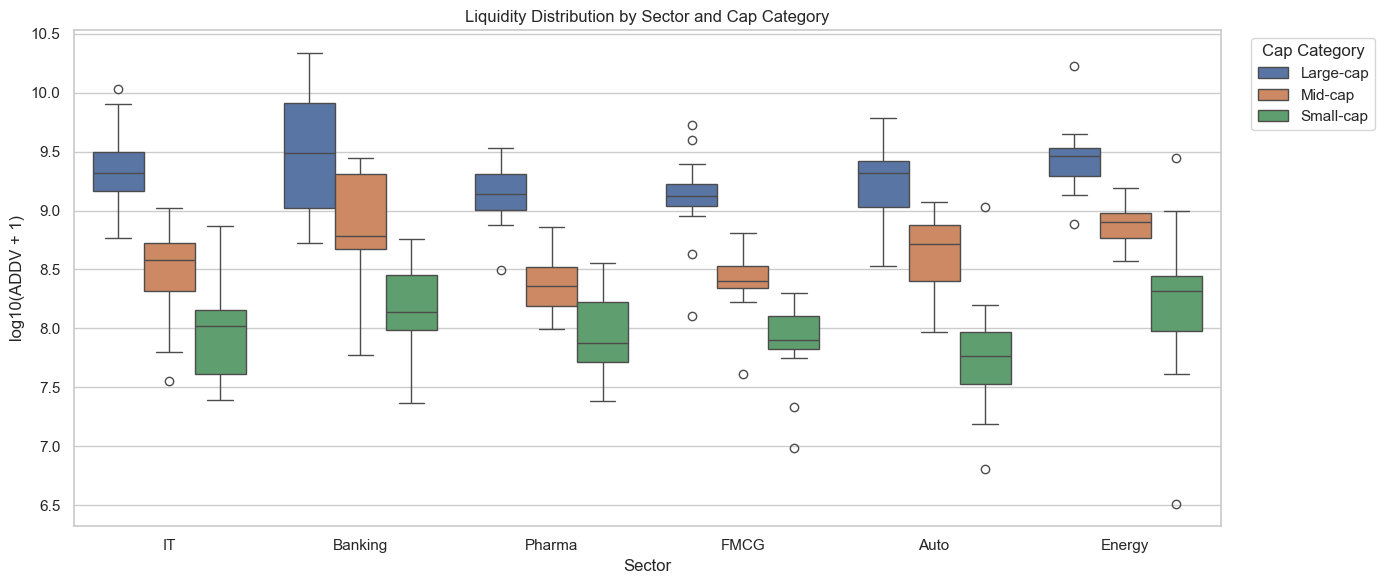

In [12]:
plot_df = metrics[metrics["ADDV"].notna()].copy()
plot_df["log10_ADDV"] = np.log10(plot_df["ADDV"].clip(lower=0) + 1)

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=plot_df,
    x="Sector",
    y="log10_ADDV",
    hue="Cap Category",
    order=SECTORS,
    hue_order=CAP_CATEGORIES,
)
plt.title("Liquidity Distribution by Sector and Cap Category")
plt.xlabel("Sector")
plt.ylabel("log10(ADDV + 1)")
plt.legend(title="Cap Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Visualization: Market-cap Category Distribution

The selected set must contain exactly 10 stocks in every sector/cap bucket. This chart is an immediate visual audit of that requirement.

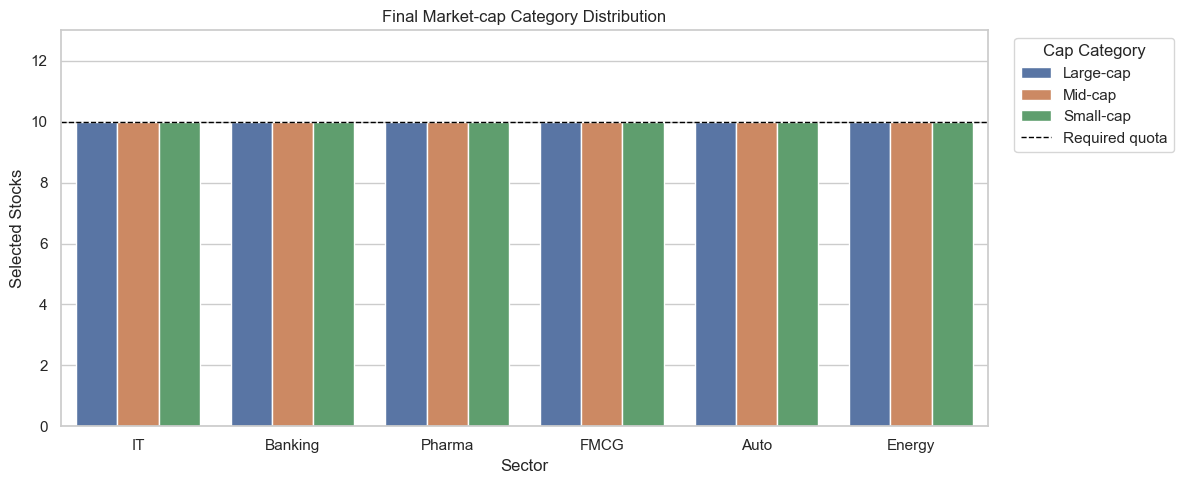

In [13]:
count_df = (
    final_selection.groupby(["Sector", "Cap Category"])
    .size()
    .rename("Selected Count")
    .reset_index()
)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=count_df,
    x="Sector",
    y="Selected Count",
    hue="Cap Category",
    order=SECTORS,
    hue_order=CAP_CATEGORIES,
)
plt.axhline(SELECTION_QUOTA, color="black", linestyle="--", linewidth=1, label="Required quota")
plt.title("Final Market-cap Category Distribution")
plt.xlabel("Sector")
plt.ylabel("Selected Stocks")
plt.ylim(0, SELECTION_QUOTA + 3)
plt.legend(title="Cap Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Visualization: Composite Scores of Final Selections

This chart reviews the final ranking scores by sector and cap category.

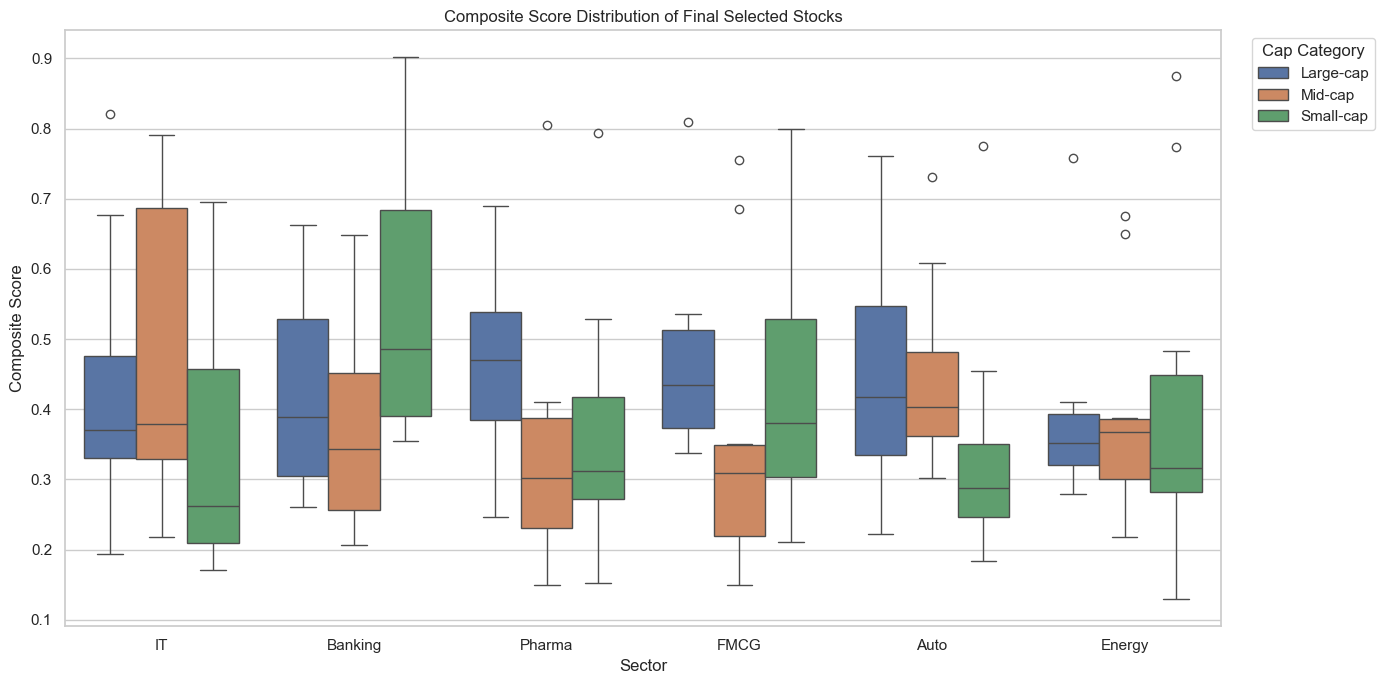

In [14]:
score_plot = final_selection.copy()
score_plot["Display"] = score_plot["Sector"] + " | " + score_plot["Cap Category"]

plt.figure(figsize=(14, 7))
sns.boxplot(
    data=score_plot,
    x="Sector",
    y="Composite Score",
    hue="Cap Category",
    order=SECTORS,
    hue_order=CAP_CATEGORIES,
)
plt.title("Composite Score Distribution of Final Selected Stocks")
plt.xlabel("Sector")
plt.ylabel("Composite Score")
plt.legend(title="Cap Category", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Export-ready Final DataFrame

`final_table` is the clean final result. It contains exactly 180 rows: 6 sectors x 3 cap categories x 10 stocks.

In [15]:
expected_shape = (len(SECTORS) * len(CAP_CATEGORIES) * SELECTION_QUOTA, len(FINAL_COLUMNS))
print("final_table shape:", final_table.shape)
print("expected shape:", expected_shape)

assert final_table.shape == expected_shape
assert set(final_table["Sector"]) == set(SECTORS)
assert set(final_table["Cap Category"]) == set(CAP_CATEGORIES)
assert (
    final_table.groupby(["Sector", "Cap Category"]).size() == SELECTION_QUOTA
).all()

final_table.head(20)

final_table shape: (180, 9)
expected shape: (180, 9)


,Ticker,Sector,Cap Category,Market Cap,Historical Return,ROE,Debt-to-Equity,Liquidity Score,Composite Score
0,CUMMINSIND.NS,Auto,Large-cap,"1,395,701,972,992.0000",4.1660,NaN,0.4310,0.5572,0.7614
1,M&M.NS,Auto,Large-cap,"3,806,416,338,944.0000",3.3993,NaN,1.2528,1.0000,0.7422
2,BAJAJ-AUTO.NS,Auto,Large-cap,"3,275,387,043,840.0000",2.5333,NaN,0.5635,0.7340,0.5672
3,BOSCHLTD.NS,Auto,Large-cap,"1,381,007,360,000.0000",2.5170,NaN,0.8000,0.3340,0.4850
4,MOTHERSON.NS,Auto,Large-cap,"1,692,368,764,928.0000",1.8204,NaN,0.4391,0.6224,0.4447
5,MARUTI.NS,Auto,Large-cap,"3,991,026,008,064.0000",0.9414,NaN,0.0960,0.9713,0.3909
6,BHARATFORG.NS,Auto,Large-cap,"935,141,376,000.0000",1.5731,NaN,0.7647,0.5205,0.3895
7,SCHAEFFLER.NS,Auto,Large-cap,"618,790,584,320.0000",1.7941,0.2165,0.7830,0.0000,0.3165
8,TIINDIA.NS,Auto,Large-cap,"522,258,120,704.0000",1.0401,NaN,0.2772,0.3385,0.2782
9,MRF.NS,Auto,Large-cap,"551,348,600,832.0000",0.6098,NaN,0.1529,0.3632,0.2226


## Sector-wise Summary: 30 Stocks Per Sector

This section groups the final 180 selected stocks into 6 sector groups of exactly 30 stocks each (10 Large-cap + 10 Mid-cap + 10 Small-cap), with detailed tables and consolidated lists.


In [16]:
## Export: 30 Stocks Per Sector

# Reconstruct final_table from final_selection when needed
if 'final_table' not in globals():
    final_table = (
        final_selection[FINAL_COLUMNS]
        .sort_values(["Sector", "Cap Category", "Composite Score"], ascending=[True, True, False])
        .reset_index(drop=True)
    )

# Build the sector-wise 30-stock display from the final selected table
sector_30_display = final_table.copy()

# Export the sector-wise 30-stock selection to CSV
export_30_per_sector = sector_30_display.copy()
export_filename = "final_selection_30_per_sector.csv"
export_30_per_sector.to_csv(export_filename, index=False)
print(f"✓ Exported 30-per-sector selection to: {export_filename}")

# Also create a compact ticker-list version for quick reference
ticker_list_by_sector = {}
for sector in SECTORS:
    tickers = sector_30_display[sector_30_display['Sector'] == sector]['Ticker'].tolist()
    ticker_list_by_sector[sector] = tickers

print("\nTicker Lists by Sector (30 per sector):")
print("-" * 80)
for sector in SECTORS:
    tickers_str = ', '.join(ticker_list_by_sector[sector])
    print(f"{sector:12} ({len(ticker_list_by_sector[sector]):2} tickers): {tickers_str}")

# Create a summary table: count verification
quota_verification = (
    sector_30_display
    .groupby(['Sector', 'Cap Category'])
    .size()
    .rename('Count')
    .reset_index()
    .pivot(index='Sector', columns='Cap Category', values='Count')
    .reindex(index=SECTORS, columns=CAP_CATEGORIES)
)

print("\n" + "="*80)
print("QUOTA VERIFICATION: Expected 10 per cap category per sector")
print("="*80)
try:
    display(quota_verification)
except NameError:
    print(quota_verification)

# Assert all quotas are met
assert (quota_verification == SELECTION_QUOTA).all().all(), "Quota mismatch detected!"
print("\n✓ All sector/cap quotas verified: 10 Large + 10 Mid + 10 Small = 30 per sector")


✓ Exported 30-per-sector selection to: final_selection_30_per_sector.csv

Ticker Lists by Sector (30 per sector):
--------------------------------------------------------------------------------
IT           (30 tickers): OFSS.NS, PERSISTENT.NS, TCS.NS, COFORGE.NS, INFY.NS, KPITTECH.NS, HCLTECH.NS, TECHM.NS, NAUKRI.NS, TATAELXSI.NS, ECLERX.NS, RATEGAIN.NS, DATAMATICS.NS, NEWGEN.NS, ZENSARTECH.NS, INTELLECT.NS, ACCELYA.NS, SONATSOFTW.NS, NUCLEUS.NS, RSYSTEMS.NS, ONEPOINT.NS, 63MOONS.NS, AURIONPRO.NS, FSL.NS, NELCO.NS, RAMCOSYS.NS, KELLTONTEC.NS, MINDTECK.NS, CONTROLPR.NS, ONWARDTEC.NS
Banking      (30 tickers): INDIANB.NS, MAHABANK.NS, UNIONBANK.NS, CANBK.NS, ICICIBANK.NS, SBIN.NS, PNB.NS, BANKBARODA.NS, KOTAKBANK.NS, AXISBANK.NS, KARURVYSYA.NS, SOUTHBANK.NS, IOB.NS, KTKBANK.NS, FEDERALBNK.NS, RBLBANK.NS, IDFCFIRSTB.NS, AUBANK.NS, YESBANK.NS, CUB.NS, J&KBANK.NS, UJJIVANSFB.NS, CREDITACC.NS, TMB.NS, EQUITASBNK.NS, SBFC.NS, SURYODAY.NS, MASFIN.NS, FUSION.NS, UTKARSHBNK.NS
Pharma       (30

Cap Category,Large-cap,Mid-cap,Small-cap
Sector,,,
IT,10,10,10
Banking,10,10,10
Pharma,10,10,10
FMCG,10,10,10
Auto,10,10,10
Energy,10,10,10



✓ All sector/cap quotas verified: 10 Large + 10 Mid + 10 Small = 30 per sector
